# 03 - The encoder, and how it learns without labels

**What this step does.** Builds the shared GIN encoder, explains Deep Graph
Infomax, trains it on **one** domain (Cora), and then asks whether the
pretraining actually improved the representation - with a measurement, not
just a picture.

**Why it exists.** Everything so far has been preparation. This is the first
notebook where something is learned. Two ideas have to be understood before
the four-arm comparison means anything:

- **Why GIN**, and not GCN or GraphSAGE. The answer is about what an
  aggregator can and cannot distinguish.
- **How DGI learns from no labels at all.** If this is hazy, arm A versus arm
  B is just two numbers.

This notebook is also the honest dress rehearsal. Running one domain properly
here is how we find out whether the method works *before* committing to a
12-run matrix.

**What could go wrong.**
- **A pretext task that is too easy.** DGI learns by telling real nodes from
  corrupted ones. If that becomes trivial, the loss hits zero, gradients
  vanish, and training continues to no effect while every curve looks healthy.
- **BatchNorm on the output layer.** This one actually happened during
  development, and it is instructive - see section 3.
- **Trusting t-SNE.** t-SNE produces convincing clusters from pure noise. Any
  claim made from it has to be backed by a number that does not depend on a
  2D projection.
- **Assuming pretraining must help.** It might not. The point of the project
  is to find out, so the measurement below is reported whichever way it lands.

## Setup

Rebuilding the 133-dim features from notebook 02. Same seed, same splits, so
these are exactly the inputs the real runs will use.

In [1]:
import pathlib
import sys

_here = pathlib.Path.cwd().resolve()
PROJECT_ROOT = next(p for p in [_here, *_here.parents] if (p / "src" / "config.py").exists())
sys.path.insert(0, str(PROJECT_ROOT)) if str(PROJECT_ROOT) not in sys.path else None

import numpy as np
import pandas as pd
import torch

from src import (analysis, batching, config, datasets, features, models,
                 plotting, pretrain, splits)
from src.seeding import set_seed

SEED = 0
set_seed(SEED)
plotting.use_project_style()
device = config.get_device()

DOMAIN = "cora"
domain = features.symmetrize_domain(datasets.load_domain(DOMAIN, verbose=False), verbose=False)
split = splits.make_node_split(domain, seed=SEED)
structural = features.structural_features_for_domain(domain, verbose=False)
X, transform, _ = features.build_unified_features(
    domain, split, seed=SEED, svd_scaling="block", structural=structural, verbose=False
)
y = splits.pooled_labels(domain)

print(f"domain   : {domain.display_name}")
print(f"features : {X.shape}  (128 SVD + 5 structural)")
print(f"splits   : train {len(split.train_idx):,} | val {len(split.val_idx):,} | test {len(split.test_idx):,}")
print(f"device   : {device}")

domain   : Cora (citation)
features : (2708, 133)  (128 SVD + 5 structural)
splits   : train 1,624 | val 542 | test 542
device   : cuda


## 1. What a GIN layer does

One layer, in words:

> A node's new representation is an MLP applied to **(its own features, scaled
> by 1+eps) plus the SUM of its neighbours' features**.

The word doing the work is **SUM**.

Consider a node with three neighbours that all look identical, versus a node
with just one such neighbour. Under **mean** aggregation these are
indistinguishable - the average of three identical vectors is that vector. Under
**max**, likewise. Only **sum** keeps the difference.

That is not a detail. It is the reason GIN is provably as powerful as the
Weisfeiler-Lehman graph isomorphism test, the strongest thing a message-passing
network can be. For a project asking whether *structural* knowledge transfers
between domains, an encoder that can actually perceive structure is the whole
premise.

**Why only two layers.** Each layer extends a node's view by one hop, so two
layers means each node sees its 2-hop neighbourhood. Deeper GNNs tend to
*over-smooth*: after many rounds of mixing with neighbours, every node
converges toward the same vector and the representation stops telling nodes
apart. Two layers is the standard compromise, and it has a second benefit we
exploit in `src/batching.py` - a known, finite receptive field.

In [2]:
encoder = models.build_encoder()
print(encoder)
print()
print(f"parameters: {encoder.num_parameters:,}")
print(f"input {encoder.in_dim} -> hidden {encoder.hidden_dim} -> output {encoder.out_dim}")

GINEncoder(
  (convs): ModuleList(
    (0): GINConv(nn=Sequential(
      (0): Linear(in_features=133, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=256, bias=True)
    ))
    (1): GINConv(nn=Sequential(
      (0): Linear(in_features=256, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=128, bias=True)
    ))
  )
  (norms): ModuleList(
    (0): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)

parameters: 200,322
input 133 -> hidden 256 -> output 128


Let us watch the shapes move through it. Note the encoder is *untrained* here -
we only care about dimensions for the moment.

In [3]:
xb = torch.as_tensor(X, dtype=torch.float32)
ei = domain.graphs[0].edge_index

print(f"input  x          : {tuple(xb.shape)}")
print(f"input  edge_index : {tuple(ei.shape)}   ({ei.size(1):,} directed edges)")
z = encoder.embed(xb, ei)
print(f"output embedding  : {tuple(z.shape)}   dtype={z.dtype}")
print()
print("node 0 embedding, first 10 of 128 dims:")
print("  ", np.array2string(z[0, :10].numpy(), precision=3))
print()
print("A node's embedding depends on its 2-hop neighbourhood. Node 0 has")
print(f"  {int((ei[1] == 0).sum())} direct neighbours, and the encoder mixed them in.")

input  x          : (2708, 133)
input  edge_index : (2, 10556)   (10,556 directed edges)
output embedding  : (2708, 128)   dtype=torch.float32

node 0 embedding, first 10 of 128 dims:
   [-0.202  0.254 -0.128 -0.409 -0.071  0.186  0.222  0.29  -0.109  0.426]

A node's embedding depends on its 2-hop neighbourhood. Node 0 has
  3 direct neighbours, and the encoder mixed them in.


## 2. Deep Graph Infomax: learning with no labels

DGI turns representation learning into a game the encoder must win.

1. **Encode the real graph** to get one vector per node: `H`.
2. **Summarise the whole graph** into a single vector: `s = sigmoid(mean(H))`.
3. **Build a fake graph.** Keep every edge exactly as it is, but *shuffle the
   rows of the feature matrix*. Node 5 now wears node 900's features while
   keeping node 5's neighbourhood.
4. **Encode the fake graph** the same way: `H~`.
5. **Score** every real node and every fake node against the summary, using a
   bilinear discriminator `score(h, s) = h.T W s`.
6. **Train** so real nodes score high and fake nodes score low - ordinary
   binary cross-entropy.

**Why this teaches anything.** The corruption leaves the graph's structure
completely untouched - same edges, same degree distribution, same density. So
the encoder cannot win by noticing something superficial about graph size or
connectivity. The *only* difference between real and fake is whether each
node's content belongs with its structural context. To win, the encoder has to
model how content and structure fit together, and that is a genuinely useful
thing to know.

**Why the summary matters.** Asking "does this node belong to *this graph*"
compares each node against a global summary, which pushes each node embedding
to carry information beyond its own immediate neighbourhood.

**Where the labels are.** Nowhere. `y` is not read anywhere in `src/models.py`
or `src/pretrain.py`. Labels first appear at the probe, in notebook 04.

In [4]:
# The corruption, made concrete on a tiny example.
set_seed(SEED)
toy = torch.arange(20, dtype=torch.float32).reshape(5, 4)
print("real features (5 nodes x 4 dims):")
print(toy.numpy())
print("\ncorrupted (same tensor, rows permuted):")
print(models.corrupt_features(toy).numpy())
print("\nThe EDGES are untouched -- only which node wears which feature row changed.")

real features (5 nodes x 4 dims):
[[ 0.  1.  2.  3.]
 [ 4.  5.  6.  7.]
 [ 8.  9. 10. 11.]
 [12. 13. 14. 15.]
 [16. 17. 18. 19.]]

corrupted (same tensor, rows permuted):
[[16. 17. 18. 19.]
 [ 0.  1.  2.  3.]
 [ 4.  5.  6.  7.]
 [12. 13. 14. 15.]
 [ 8.  9. 10. 11.]]

The EDGES are untouched -- only which node wears which feature row changed.


## 3. One bug worth keeping in the notebook

While building this, the loss fell nicely to 0.693 and stayed there, while the
discriminator sat at exactly 50% accuracy - chance. Everything *looked* like
training.

0.693 is `ln(2)`: the loss of a discriminator that outputs zero for
everything. The cause was BatchNorm on the encoder's **output** layer.
BatchNorm forces each dimension to mean ~0 across nodes, and the DGI summary
is `sigmoid(mean over nodes)` - so the summary became a constant ~0.5 vector,
identical for the real graph and the corrupted one. There was nothing to
discriminate.

The fix is one line: normalise *between* layers, never on the output. It is
worth keeping visible because it is the exact failure mode this notebook warns
about - a metric that looks plausible while no learning is happening. Always
check the discriminator accuracy, not only the loss.

In [5]:
print("normalisation layers:", len(encoder.norms), "for", encoder.num_layers, "conv layers")
print("-> the final layer has no BatchNorm and no activation.\n")

z = encoder.embed(xb, ei)
summary = models.DeepGraphInfomax.summarise(z)
print(f"per-dimension mean of H : {z.mean(dim=0).abs().mean():.4f}  (not forced to 0)")
print(f"summary vector spread   : std {summary.std():.4f}, "
      f"range [{summary.min():.3f}, {summary.max():.3f}]")
print("\nIf this summary had std ~0.000 and sat at 0.5, DGI could not learn.")
assert summary.std() > 1e-3, "summary vector is constant -- DGI cannot learn"

normalisation layers: 1 for 2 conv layers
-> the final layer has no BatchNorm and no activation.

per-dimension mean of H : 0.7598  (not forced to 0)
summary vector spread   : std 0.1975, range [0.070, 0.954]

If this summary had std ~0.000 and sat at 0.5, DGI could not learn.


## 4. Train it

One step = one batch. Cora is small enough to use whole, so each step sees the
entire graph. Early stopping watches the DGI loss itself, because there is no
validation label to watch - DGI never sees one.

In [6]:
set_seed(SEED)
encoder_random = models.build_encoder().to(device)     # arm B: never trained
emb_random = batching.full_embeddings(encoder_random, domain, X, device)

set_seed(SEED)
encoder_trained, history = pretrain.pretrain_single_domain(
    models.build_encoder(), domain, X, device,
    steps=300, lr=1e-3, patience=30, seed=SEED, log_every=25,
)
emb_trained = batching.full_embeddings(encoder_trained.to(device), domain, X, device)

print()
print(f"embeddings: {emb_random.shape} (random) and {emb_trained.shape} (trained)")

  pretraining on cora | full graph


    step    1/300  loss 1.2198  disc acc 0.462


    step   25/300  loss 0.0627  disc acc 0.994


    step   50/300  loss 0.0033  disc acc 1.000


    step   75/300  loss 0.0040  disc acc 1.000


    step  100/300  loss 0.0003  disc acc 1.000


    step  125/300  loss 0.0001  disc acc 1.000


    step  150/300  loss 0.0001  disc acc 1.000


    step  175/300  loss 0.0001  disc acc 1.000


    step  200/300  loss 0.0001  disc acc 1.000
    early stop at step 202 (no improvement for 30 steps)
    done in 3.8s | best loss 0.0001 at step 172

embeddings: (2708, 128) (random) and (2708, 128) (trained)


saved -> D:\documents\my projects\afterPFE\OmniGraph\results\figures\03_dgi_loss_curve.png


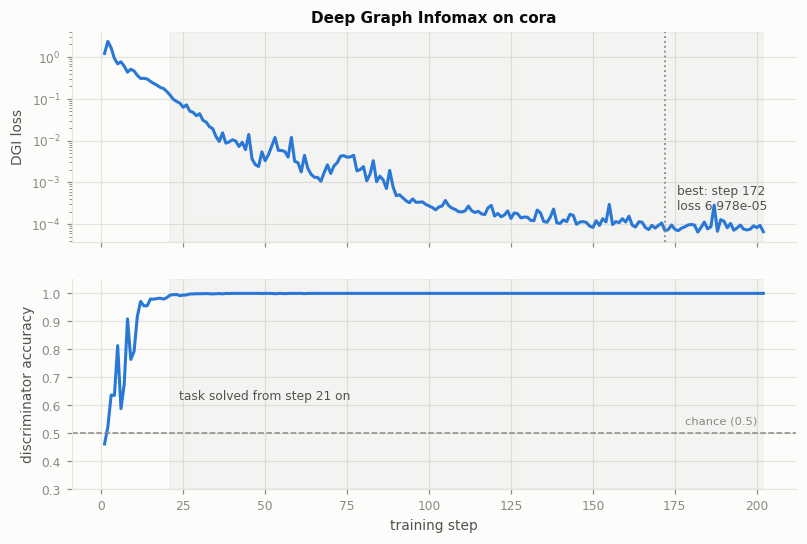

In [7]:
fig = plotting.plot_pretrain_curve(history, DOMAIN)

### Read that curve carefully

The loss falls by orders of magnitude and the discriminator reaches **100%
accuracy**. It is tempting to call that a success. It is better described as
**the pretext task being solved**, and that has a consequence: once every real
node scores above every fake one, the cross-entropy gradient is almost zero.
Training continues but there is nothing left to learn from.

A solved pretext task is not the same as a good representation. Whether the
representation actually improved is a separate question, and it needs a
separate measurement.

## 5. Did pretraining help?

Three measurements, none of which depend on a 2D projection:

- **k-NN accuracy** - do same-class nodes end up near each other? Trains no
  weights at all, so it measures the geometry of the representation itself.
- **Linear probe accuracy** - can a single linear layer read the class off the
  embedding? (A quick scikit-learn version; notebook 04 builds the real one.)
- **Effective rank** - how many dimensions the embedding actually uses. A
  collapsed encoder shows a rank far below its 128 output dims, and nothing
  downstream can recover what it discarded.

Three encoders are compared. The raw 133-dim input is included as a floor: if
the GNN does not beat *not using a GNN at all*, message passing is not earning
its place.

In [8]:
candidates = {
    "raw input (no GNN)": X,
    "B: random-init encoder": emb_random,
    "DGI-pretrained encoder": emb_trained,
}

rows = {}
for tag, emb in candidates.items():
    scores = analysis.quick_linear_probe(emb, y, split.train_idx, split.test_idx, seed=SEED)
    rows[tag] = {
        "knn_acc": analysis.knn_accuracy(emb, y, split.train_idx, split.test_idx, k=10),
        "linear_acc": scores["accuracy"],
        "linear_macro_f1": scores["macro_f1"],
        "effective_rank": analysis.embedding_health(emb)["effective_rank"],
    }

table = analysis.compare_encoders(rows)
display(table.style.format({
    "knn_acc": "{:.3f}", "linear_acc": "{:.3f}",
    "linear_macro_f1": "{:.3f}", "effective_rank": "{:.1f}",
}))

majority = float(np.bincount(y).max() / len(y))
print(f"\nmajority-class baseline: {majority:.3f}")

,knn_acc,linear_acc,linear_macro_f1,effective_rank
raw input (no GNN),0.548,0.686,0.657,127.2
B: random-init encoder,0.744,0.804,0.793,37.8
DGI-pretrained encoder,0.771,0.795,0.794,38.1



majority-class baseline: 0.302


Now the picture, to see *how* the representation is arranged. Each panel shows
one class in colour against the rest of the cloud in grey - seven hues in a
single scatter would make colour the only thing carrying identity, and not
every reader can separate seven hues reliably.

Top row is the untrained encoder, bottom row the pretrained one. If
pretraining helped, the coloured points should be tighter in the bottom row.

saved -> D:\documents\my projects\afterPFE\OmniGraph\results\figures\03_tsne_before_after.png


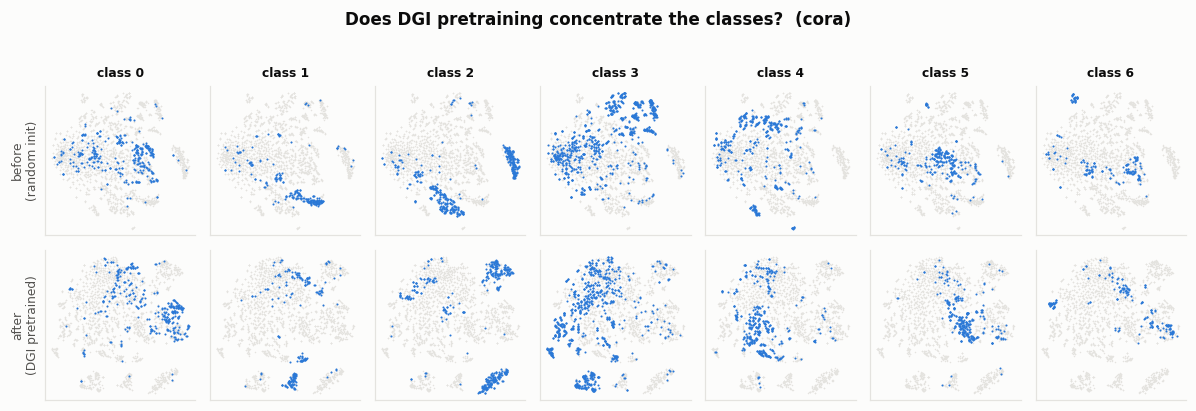

In [9]:
coords_before, idx_used = analysis.tsne_2d(emb_random, seed=SEED, subsample=3000)
coords_after, _ = analysis.tsne_2d(emb_trained, seed=SEED, subsample=3000)

fig = plotting.plot_tsne_facets(
    coords_before, coords_after, y[idx_used], DOMAIN,
    class_names=[f"class {c}" for c in np.unique(y)],
)

## 6. Is one run enough to conclude anything?

No. A single seed tells you very little, and the gap between these encoders is
small enough that seed noise could easily swamp it. Three seeds, reported with
their spread.

This is deliberately the *quick* comparison - scikit-learn probe, no early
stopping, one fold. The real protocol in notebooks 04-06 uses a proper probe
with validation-based early stopping across 4 folds and 3 seeds. The purpose
here is to catch an obvious problem early, before committing to the full
matrix.

In [10]:
records = []
for seed in [0, 1, 2]:
    set_seed(seed)
    rnd = batching.full_embeddings(models.build_encoder().to(device), domain, X, device)
    set_seed(seed)
    enc, hist = pretrain.pretrain_single_domain(
        models.build_encoder(), domain, X, device,
        steps=300, lr=1e-3, patience=30, seed=seed, verbose=False,
    )
    trn = batching.full_embeddings(enc.to(device), domain, X, device)
    records.append({
        "seed": seed,
        "random_init": analysis.quick_linear_probe(rnd, y, split.train_idx, split.test_idx)["accuracy"],
        "dgi_pretrained": analysis.quick_linear_probe(trn, y, split.train_idx, split.test_idx)["accuracy"],
        "dgi_steps": len(hist.steps),
        "dgi_final_disc_acc": hist.accuracy[-1],
    })

seeds_df = pd.DataFrame(records).set_index("seed")
display(seeds_df.style.format("{:.3f}"))

gap = seeds_df["dgi_pretrained"] - seeds_df["random_init"]
print(f"\nrandom-init    : {seeds_df['random_init'].mean():.3f} +/- {seeds_df['random_init'].std():.3f}")
print(f"DGI-pretrained : {seeds_df['dgi_pretrained'].mean():.3f} +/- {seeds_df['dgi_pretrained'].std():.3f}")
print(f"gap (DGI - random): {gap.mean():+.3f} +/- {gap.std():.3f}")
print()
if abs(gap.mean()) < gap.std():
    print("The gap is smaller than its own spread across seeds.")
    print("On this evidence, DGI pretraining on Cora is NOT distinguishable")
    print("from random initialisation. Reported as observed -- no tuning to")
    print("make it look better.")

,random_init,dgi_pretrained,dgi_steps,dgi_final_disc_acc
seed,,,,
0,0.804,0.797,202.000,1.000
1,0.788,0.801,230.000,1.000
2,0.795,0.784,224.000,1.000



random-init    : 0.796 +/- 0.008
DGI-pretrained : 0.794 +/- 0.009
gap (DGI - random): -0.002 +/- 0.013

The gap is smaller than its own spread across seeds.
On this evidence, DGI pretraining on Cora is NOT distinguishable
from random initialisation. Reported as observed -- no tuning to
make it look better.


## What you should now understand

- **GIN sums, and that is why it was chosen.** Mean and max aggregation cannot
  tell a node with three identical neighbours from one with a single such
  neighbour; sum can. That makes GIN as discriminating as the
  Weisfeiler-Lehman test, which matters for a project about whether structural
  knowledge transfers.
- **DGI learns from a game, not from labels.** Corrupt the features while
  leaving every edge intact, then ask the encoder to tell real nodes from fake
  ones. Because structure is untouched, the only way to win is to model how
  content and structure fit together. No label is read anywhere in the
  pretraining code.
- **A solved pretext task is not a good representation.** The discriminator
  reaches 100% and the loss collapses, yet on Cora the pretrained encoder is
  not measurably better than a random-initialised one across three seeds. Both
  comfortably beat using no GNN at all, which says the *message passing* is
  doing the work rather than the *pretraining*. That is a real result, not a
  bug, and it is exactly why arm B and arm D exist in the protocol.

**Next:** `04_probe.ipynb` - proper splits, the frozen-encoder linear probe
with validation-based early stopping, and arms B and C on one fold.